### Ocean Basin Masks

In [3]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.path as mpath
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from mom6_tools.m6plot import xyplot
from mom6_tools.m6toolbox import genBasinMasks 
import regionmask
import datetime
import numpy 
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [4]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [5]:
# The following parameters must be set accordingly
######################################################
# case name - must be changed for each configuration
grid_name = 'tx2_3v3'
# Path to the grid
grd_path = "../mesh/tx2_3v3_grid.nc"
# add your name and email address below
author = 'Gustavo Marques (gmarques@ucar.edu)'

In [6]:
grd = xr.open_dataset(grd_path)
grd

<xarray.Dataset>
Dimensions:  (ny: 480, nx: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: ny, nx, nxp, nyp
Data variables: (12/20)
    tlon     (ny, nx) float64 ...
    tlat     (ny, nx) float64 ...
    ulon     (ny, nxp) float64 ...
    ulat     (ny, nxp) float64 ...
    vlon     (nyp, nx) float64 ...
    vlat     (nyp, nx) float64 ...
    ...       ...
    tarea    (ny, nx) float64 ...
    tmask    (ny, nx) float64 ...
    angle    (ny, nx) float64 ...
    depth    (ny, nx) float64 ...
    ar       (ny, nx) float64 ...
    egs      (ny, nx) float64 ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

### Default basins from mom6-tools

In [7]:
basin_code = genBasinMasks(grd.tlon.values, grd.tlat.values, grd.depth.values,xda=True).rename('basin_masks')

In [8]:
basin_code

<xarray.DataArray 'basin_masks' (region: 16, yh: 480, xh: 540)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * region   (region) <U17 'Global' 'PersianGulf' ... 'GulfOfMexico'
Dimensions without coordinates: yh, xh

#### Check mask for all the regions

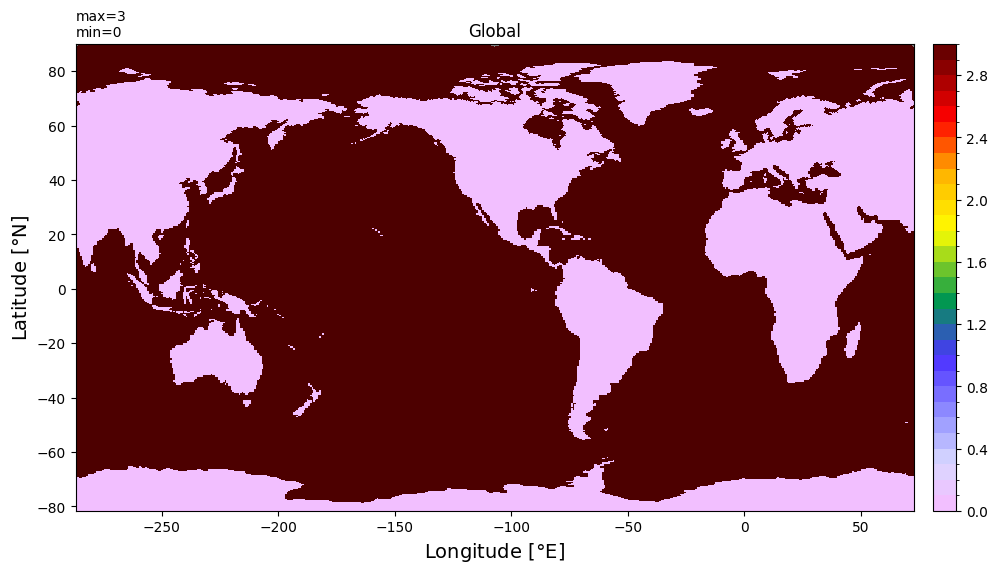

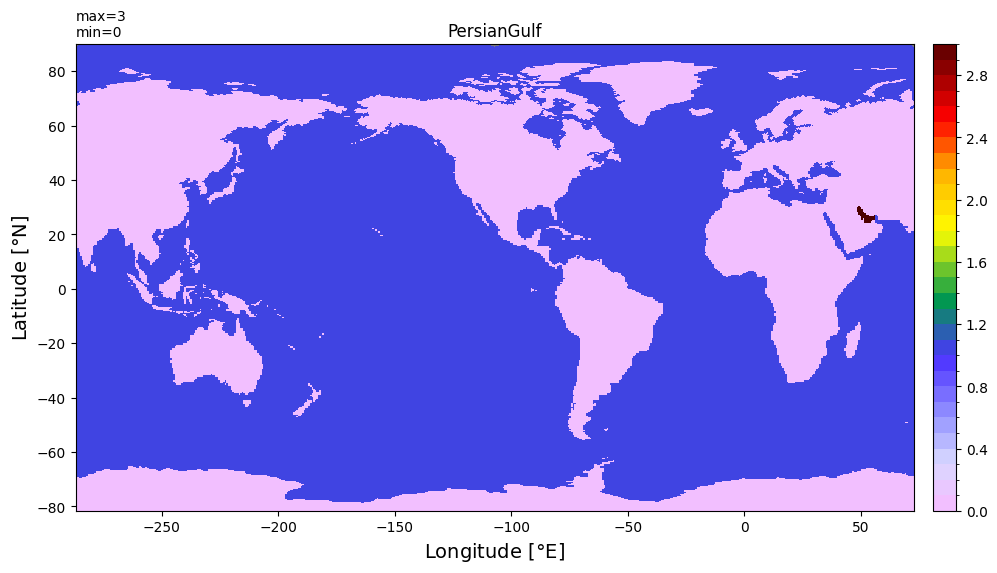

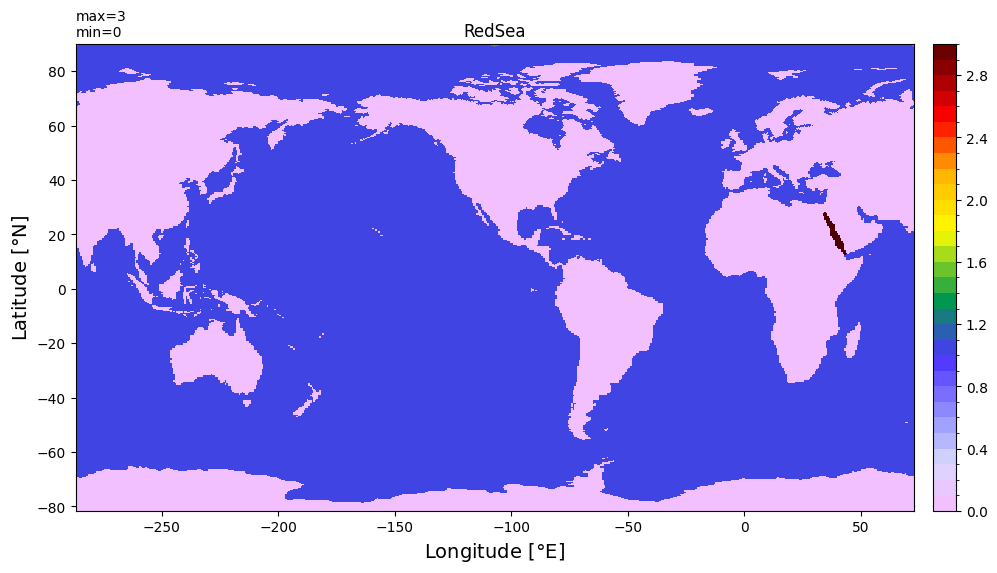

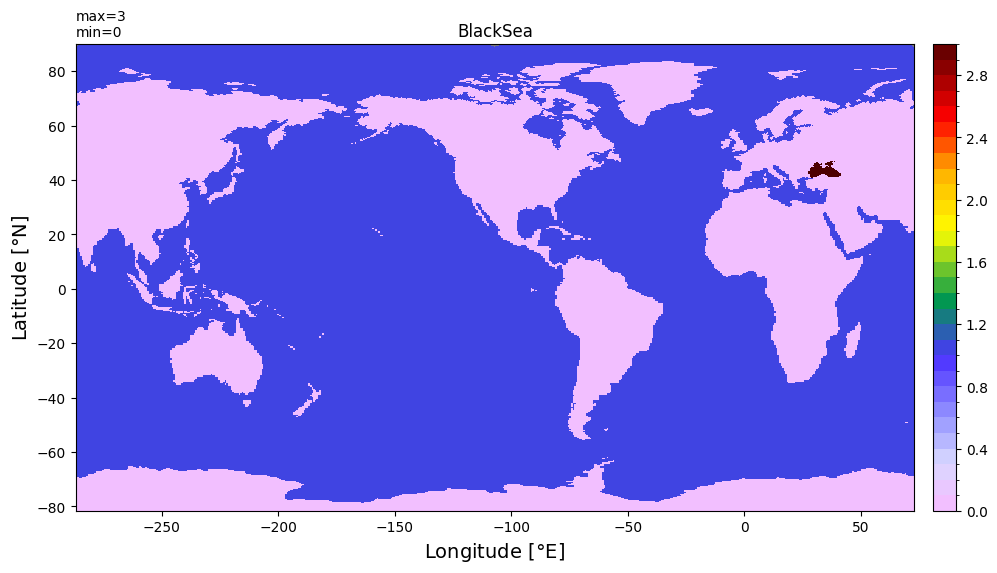

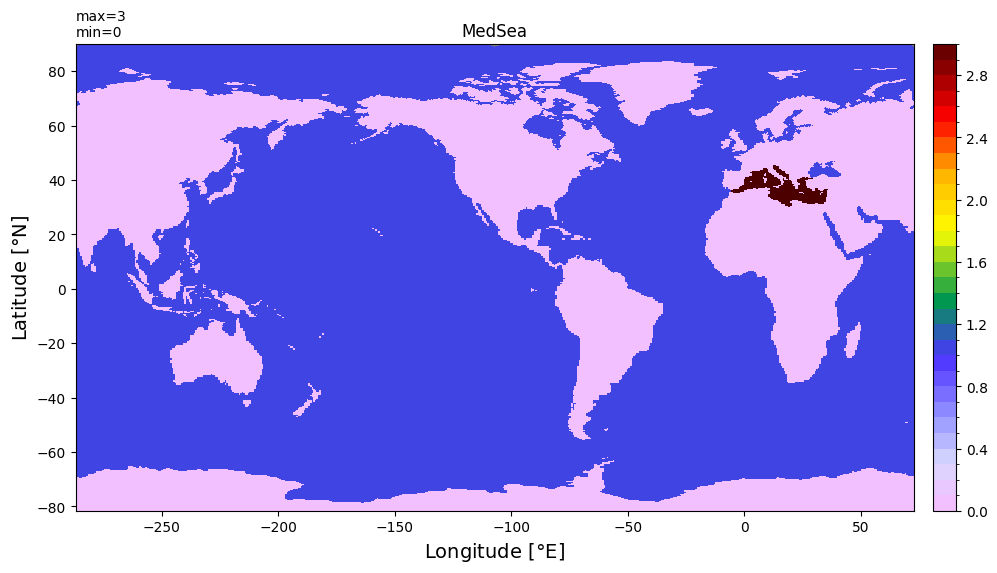

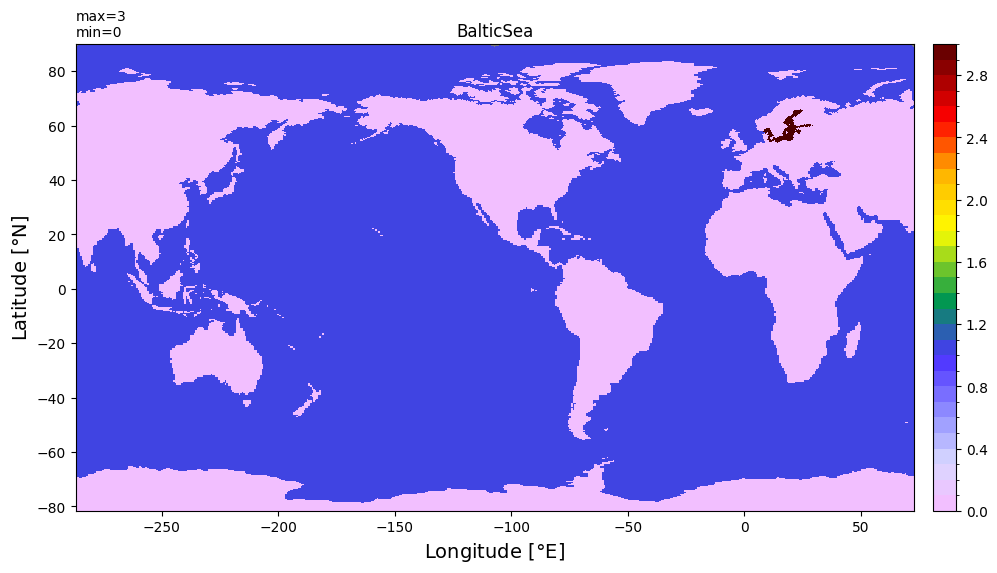

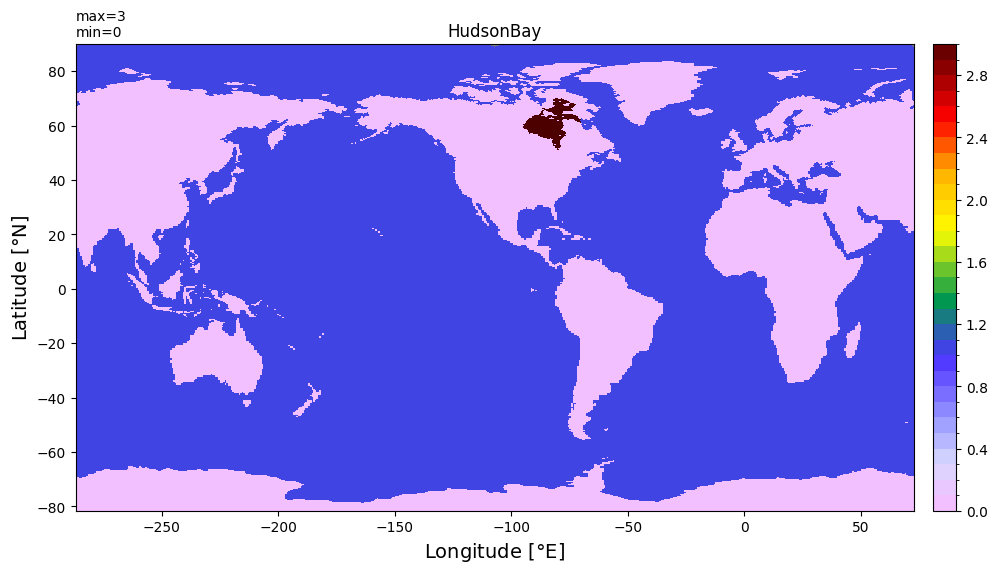

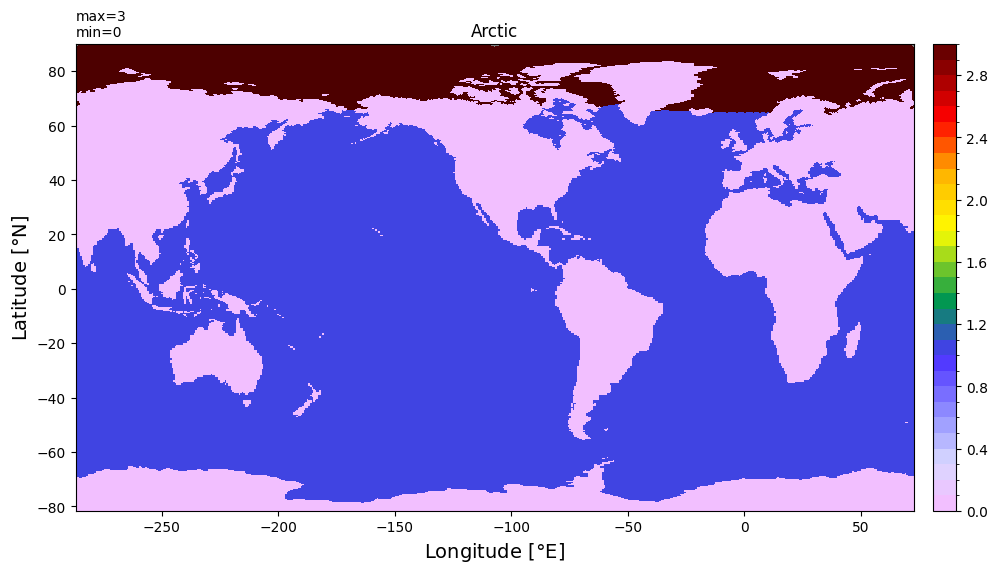

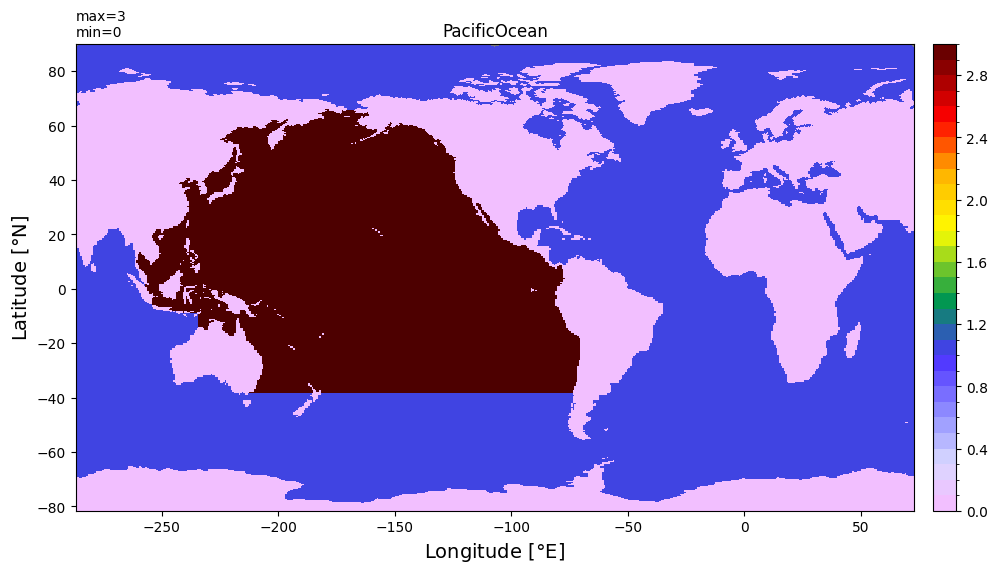

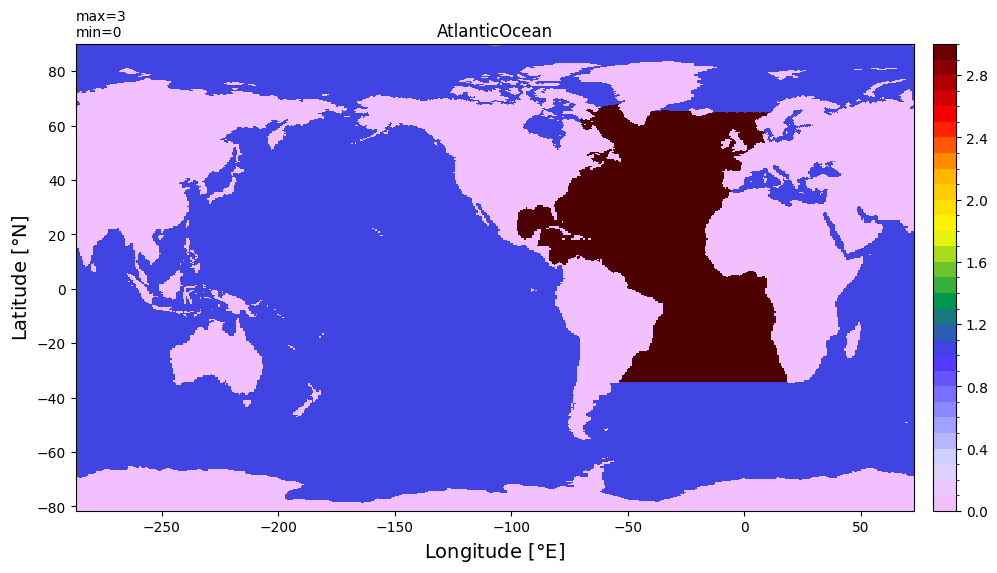

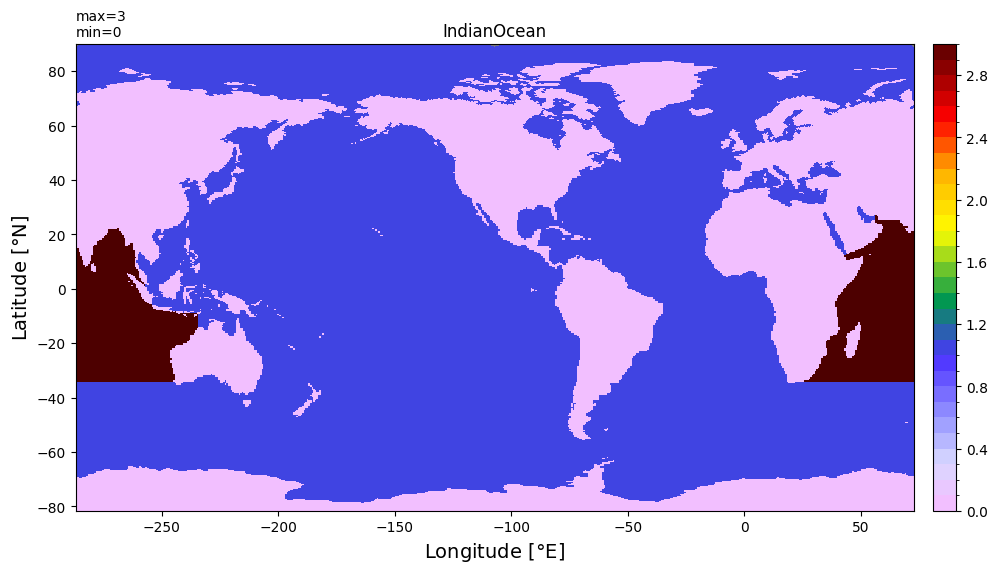

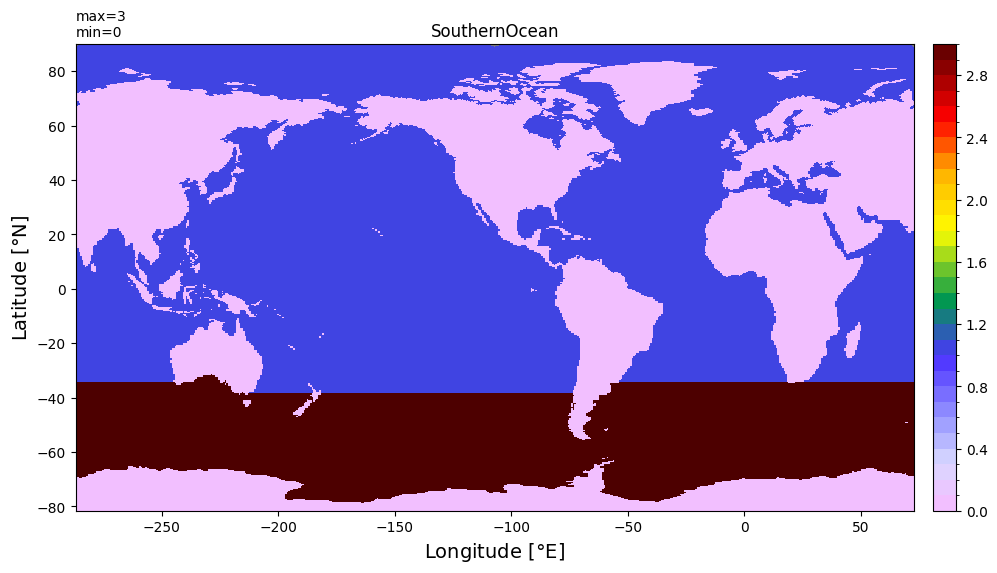

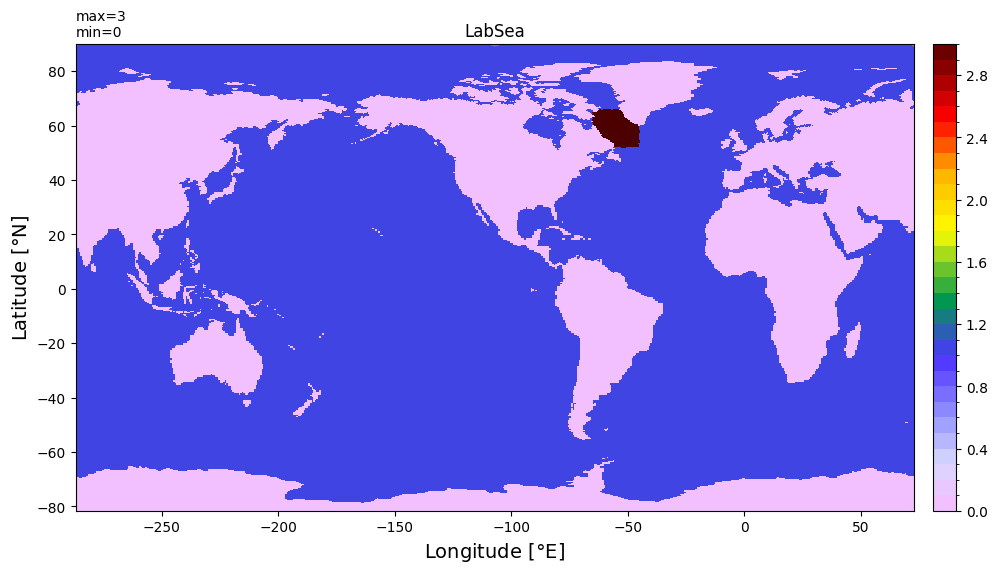

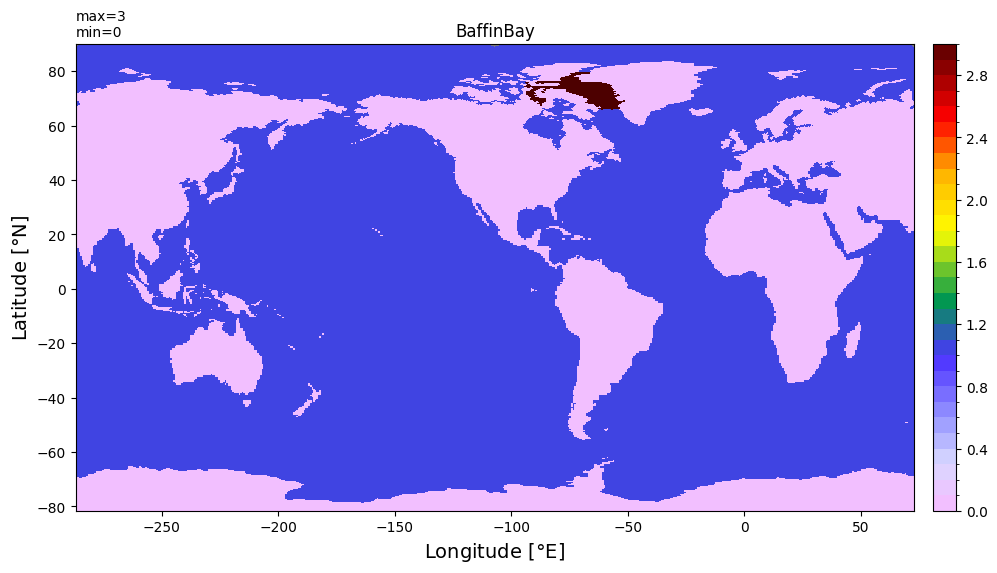

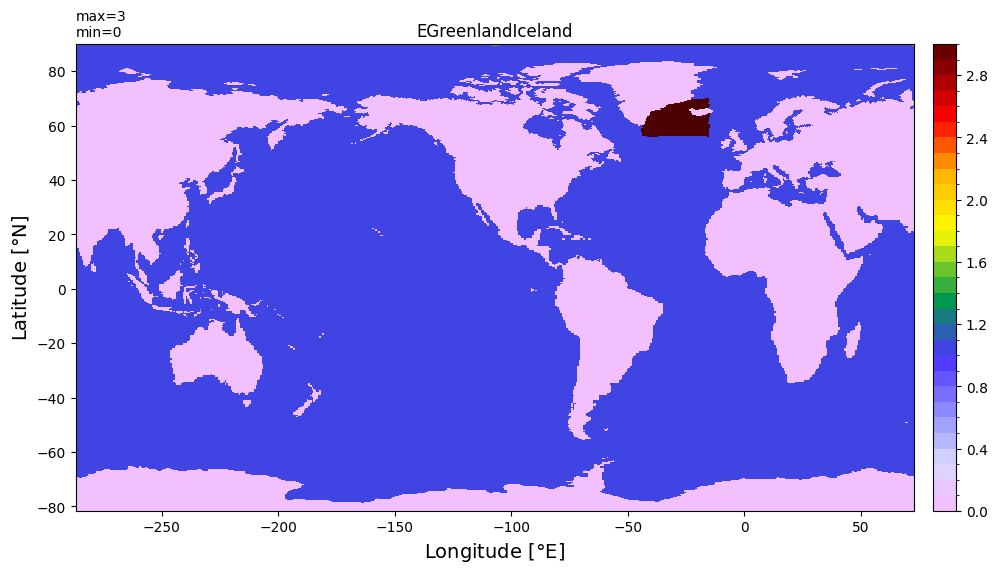

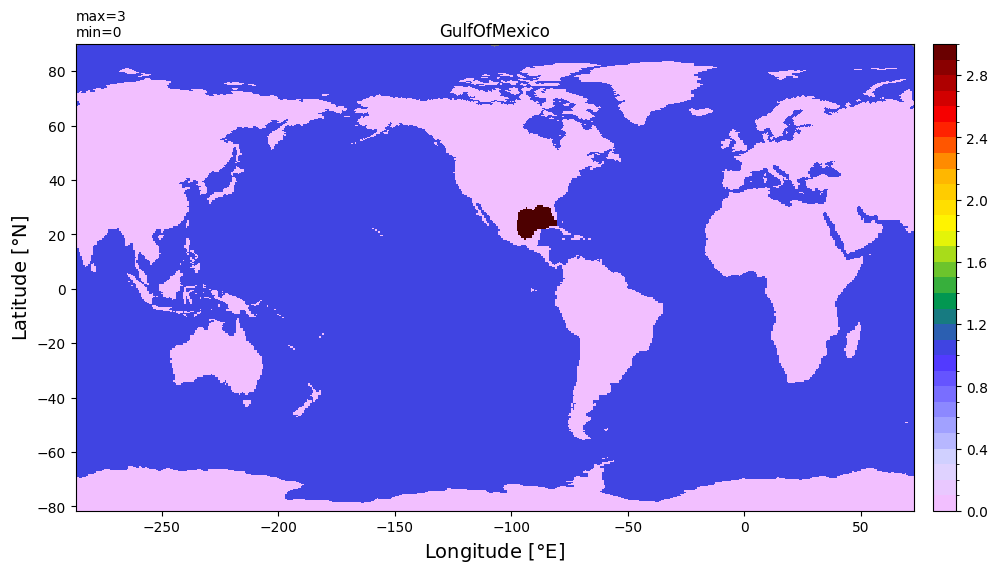

In [9]:
for r in range(len(basin_code.region)):
    xyplot((basin_code[0,:]+basin_code[r,:]*2).values, grd.tlon, grd.tlat,
          title=str(basin_code['region'][r].values))

#### Plot all masks in a single map

In [10]:
a= xr.where(basin_code[1]==1, 1, numpy.nan)

In [11]:
val_ls = []
for key, val in mcolors.TABLEAU_COLORS.items():
    val_ls.append(val)
print(val_ls)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


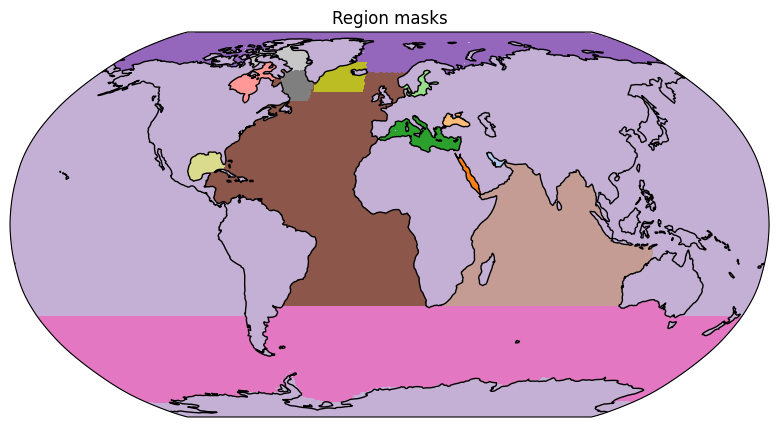

In [12]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

for r in range(1,len(basin_code.region)):
    mask= xr.where(basin_code[r,:]==1, r, numpy.nan)
    
    
    pc = ax.pcolormesh(grd.qlon, grd.qlat, mask.values, cmap=plt.cm.tab20, 
              transform=ccrs.PlateCarree(),vmin=0, vmax=(len(basin_code.region)+1))

ax.set_title('Region masks')
ax.set_global()
ax.stock_img()
ax.coastlines();

### Load basins from regionmask

<GeoAxes: >

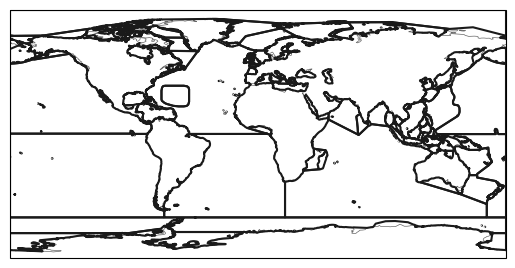

In [13]:
basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
basins.plot(add_ocean=False, add_label=False)

In [14]:
from xmip.regionmask import merged_mask
mask = merged_mask(basins,grd.rename({'tlat':'lat', 'tlon':'lon'}))
mask

<xarray.DataArray 'mask' (ny: 480, nx: 540)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Dimensions without coordinates: ny, nx

In [15]:
# Find unique values
unique_values = numpy.unique(mask)
unique_values

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       nan])

#### Check mask for all the regions

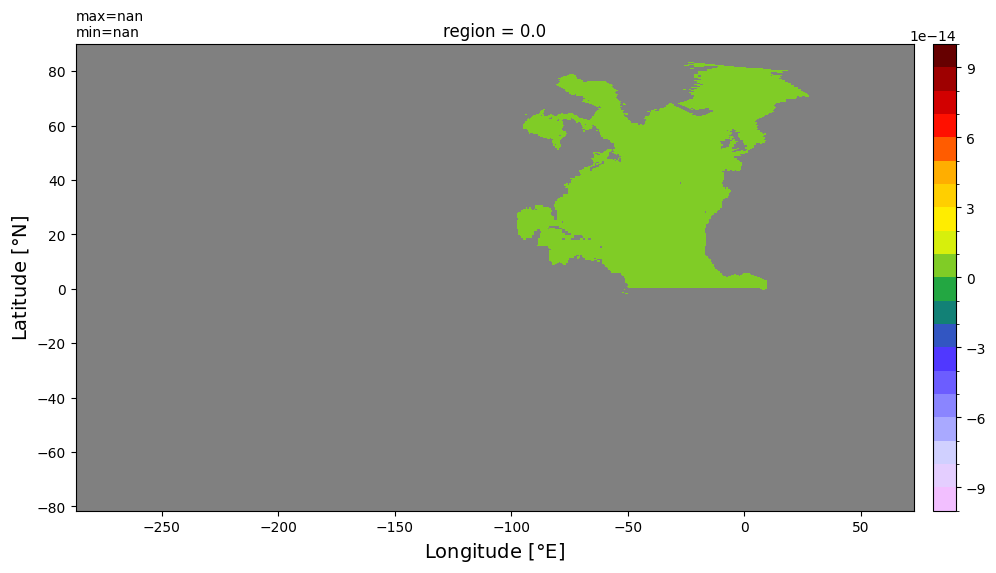

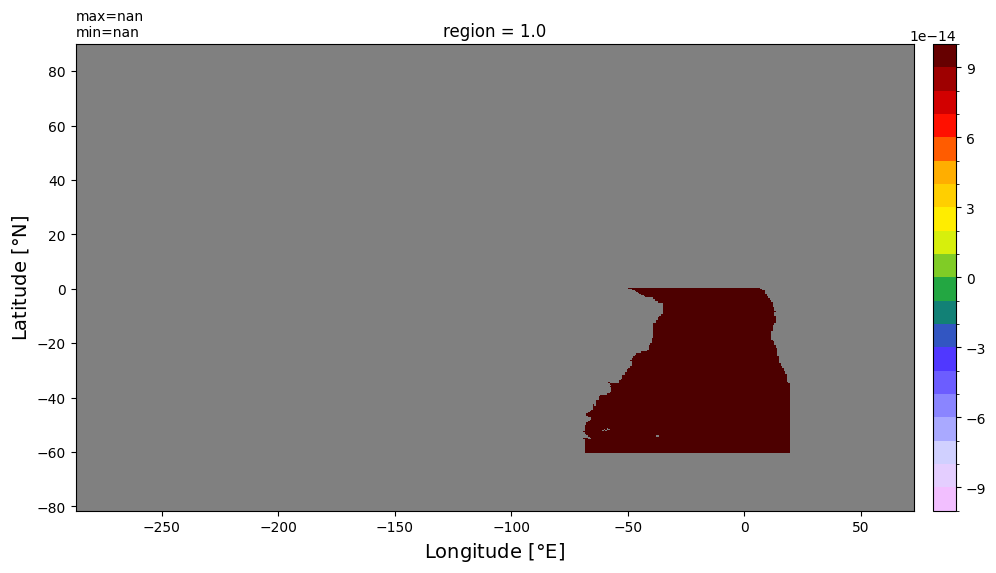

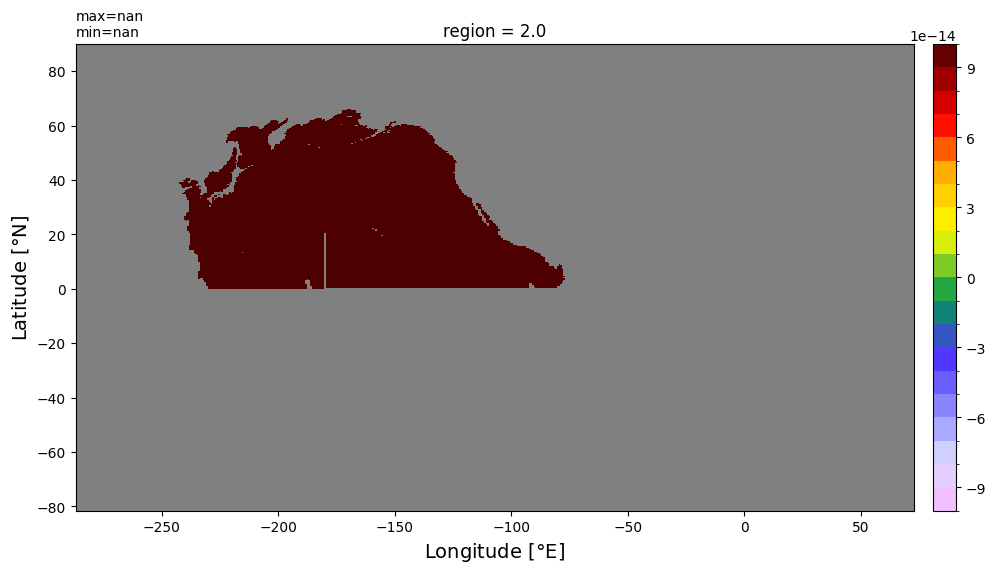

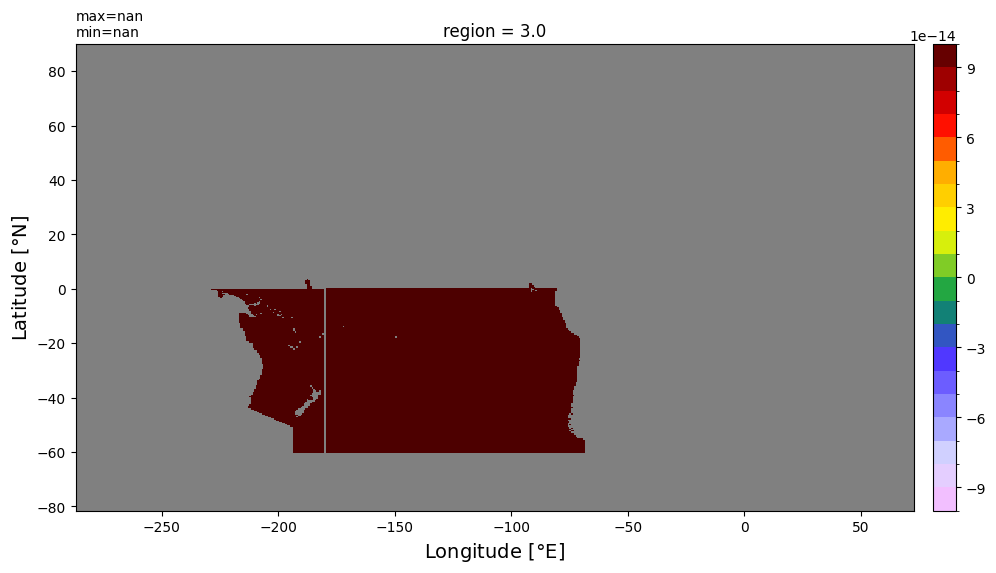

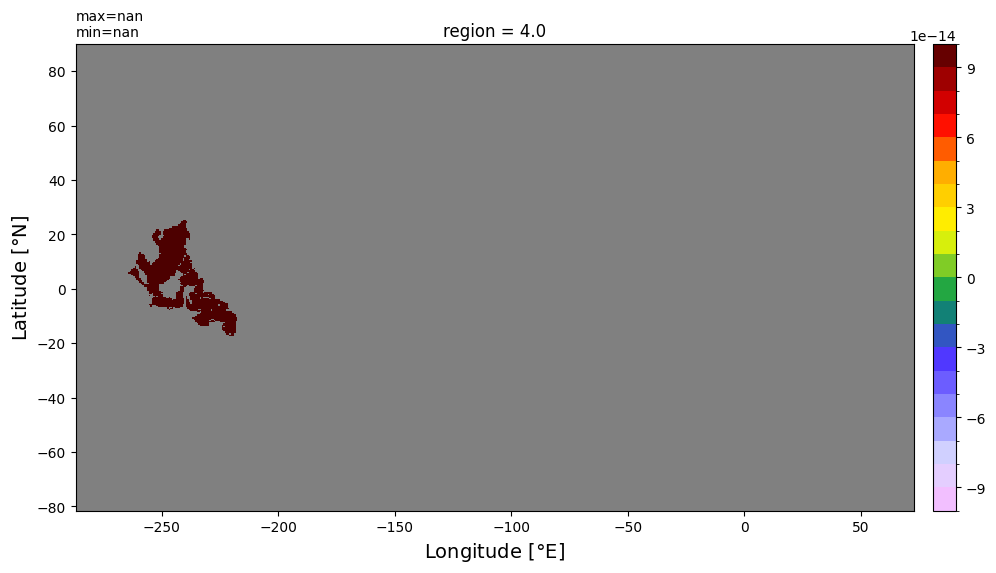

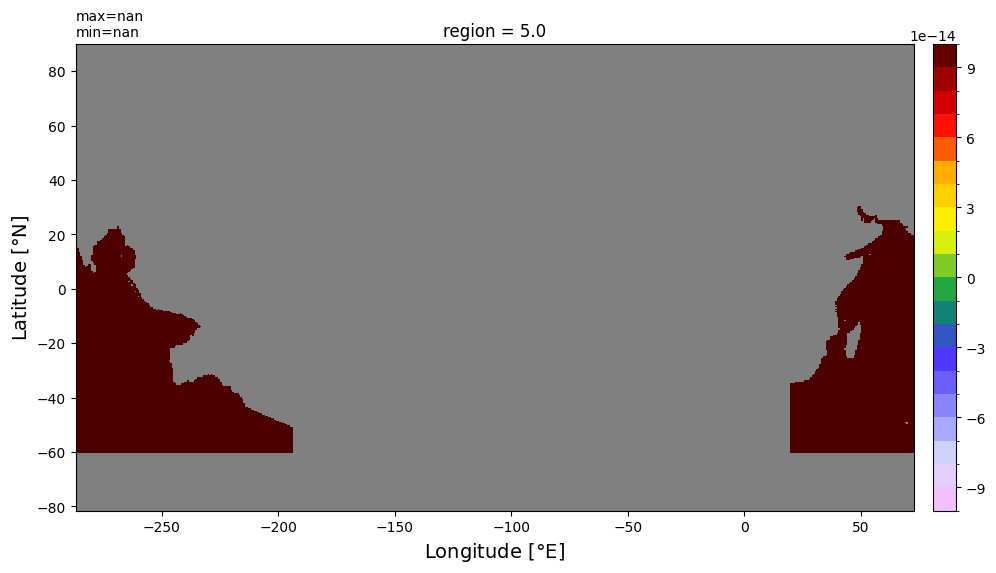

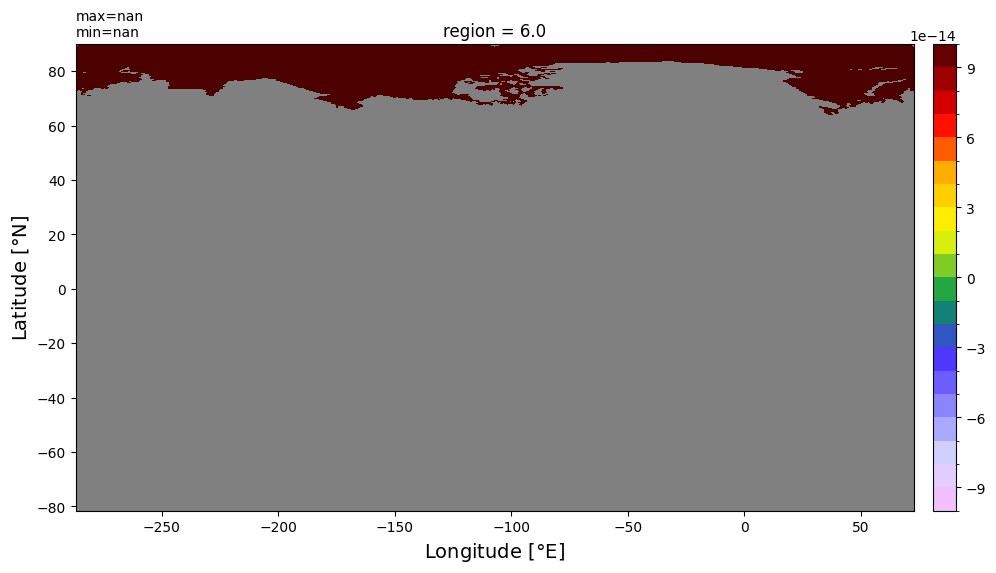

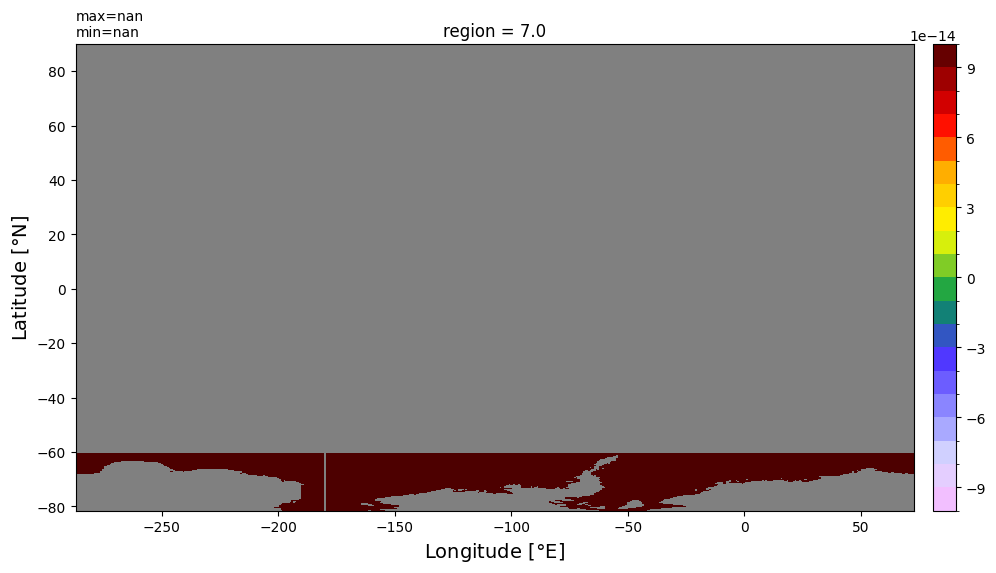

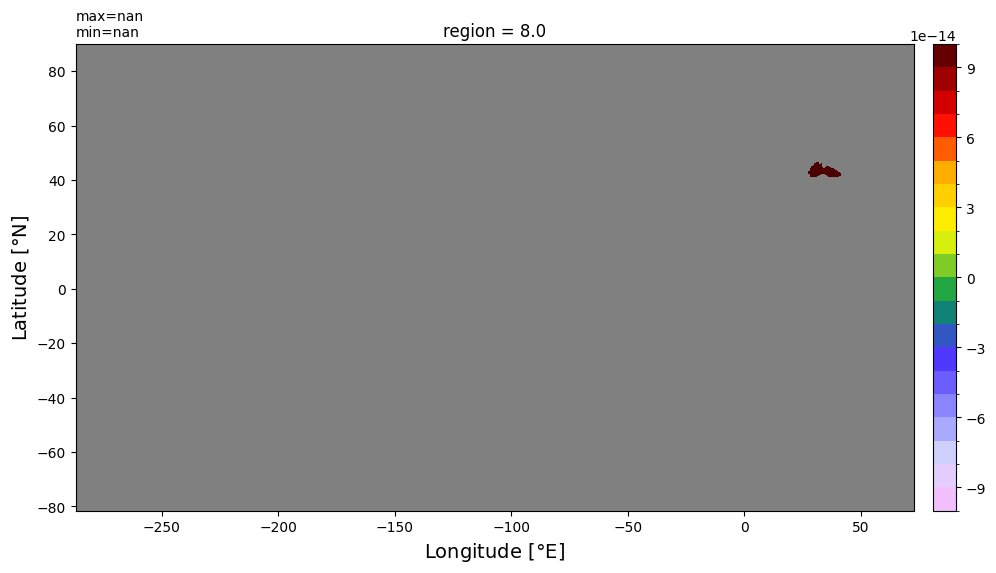

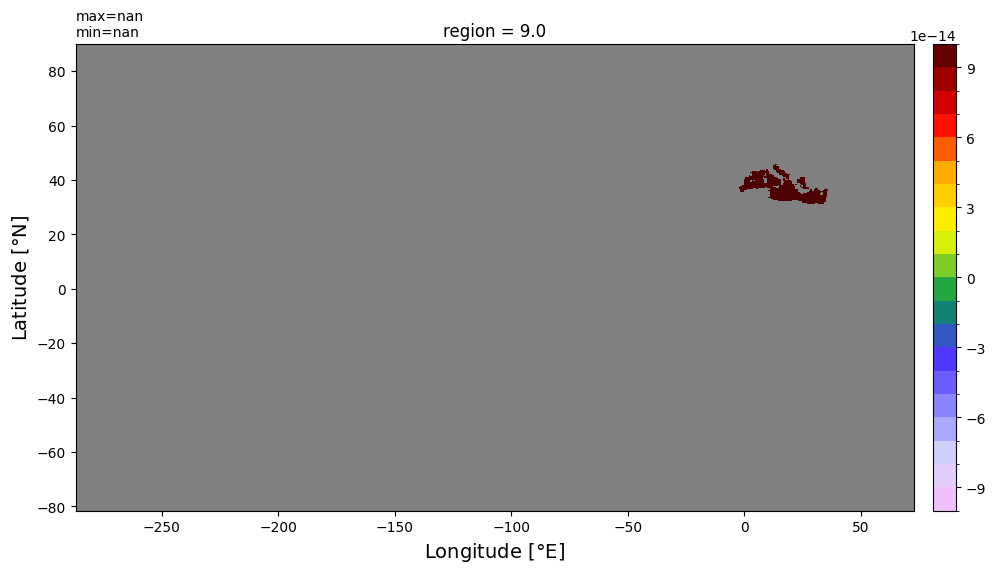

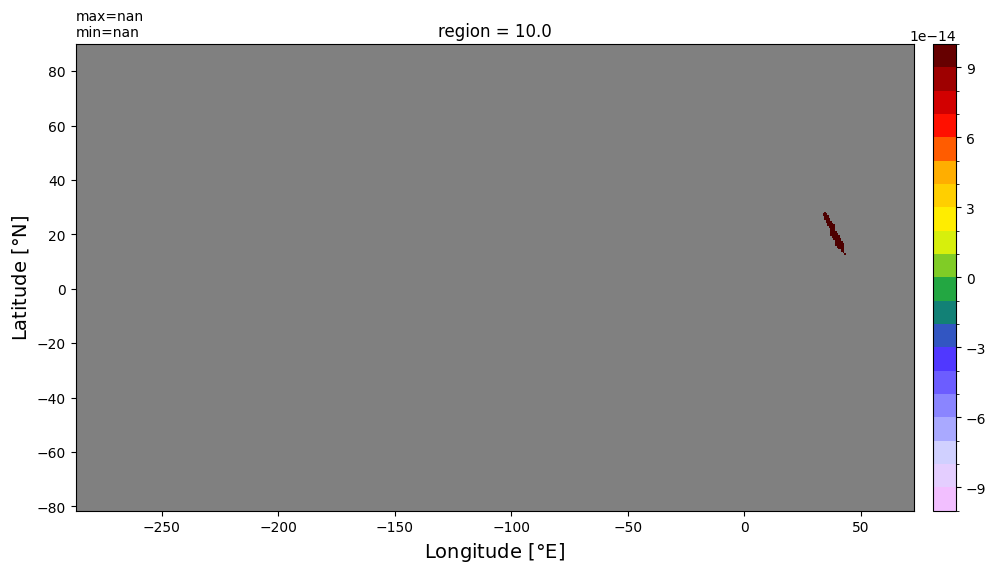

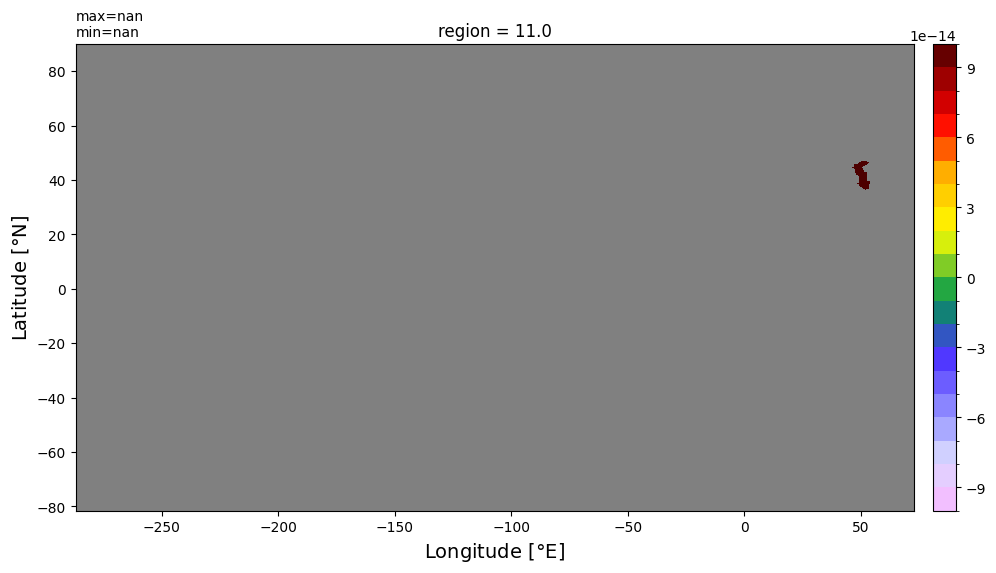

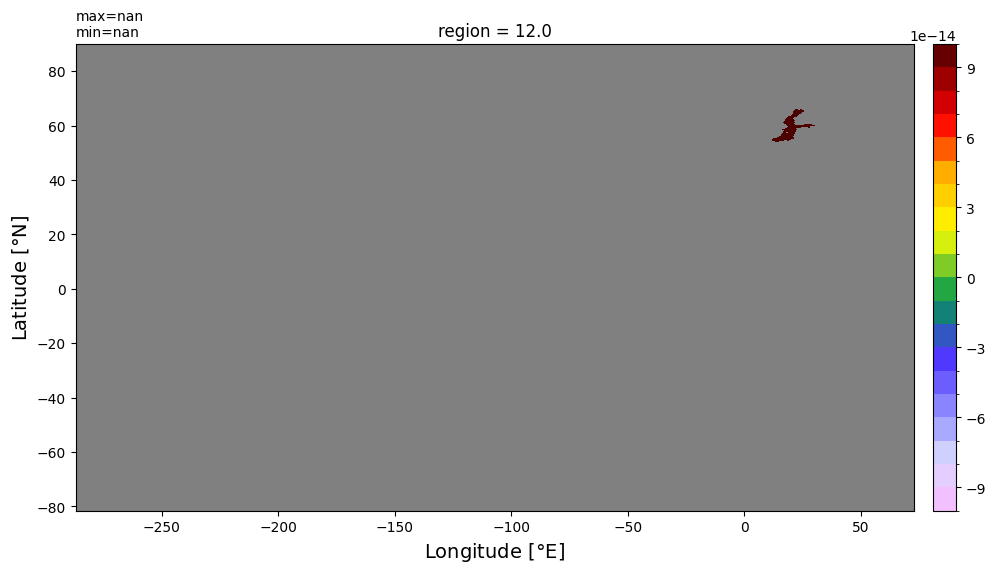

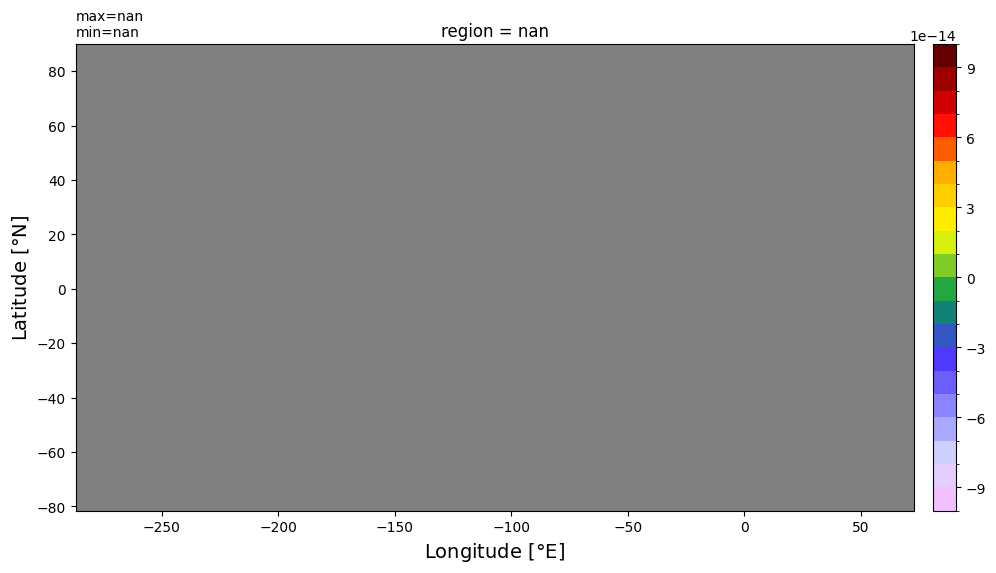

In [16]:
for r in unique_values:
    xyplot((mask.where(mask == r)).values, grd.tlon, grd.tlat,
          title='region = {}'.format(str(r)))

#### Plot all masks in a single map

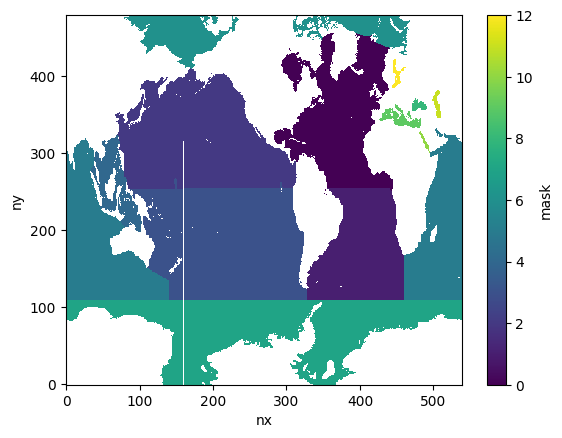

In [17]:
mask.plot()

### Add new basins into basin_code

#### Maritime

In [18]:
# Expand dimensions to match `region` dimension
new_region_mask = xr.where(mask == 4, 1, 0).rename({'ny':'yh', 'nx':'xh'}).fillna(0)

# Assign a new region index (e.g., 14 if original regions are indexed 0-13)
new_region_mask = new_region_mask.expand_dims(dim={"region": [len(basin_code.region)]})  # Change to the appropriate index

# Concatenate with the existing `basin_masks`
basin_code = xr.concat([basin_code, new_region_mask], dim="region")

# Update region name

# Convert region names to a list, modify the last element, and reassign
region_names = basin_code.region.values.tolist()
region_names[-1] = 'Maritime'  # Replace last region name

# Reassign the modified region names to the dataset
basin_code = basin_code.assign_coords(region=("region", region_names))

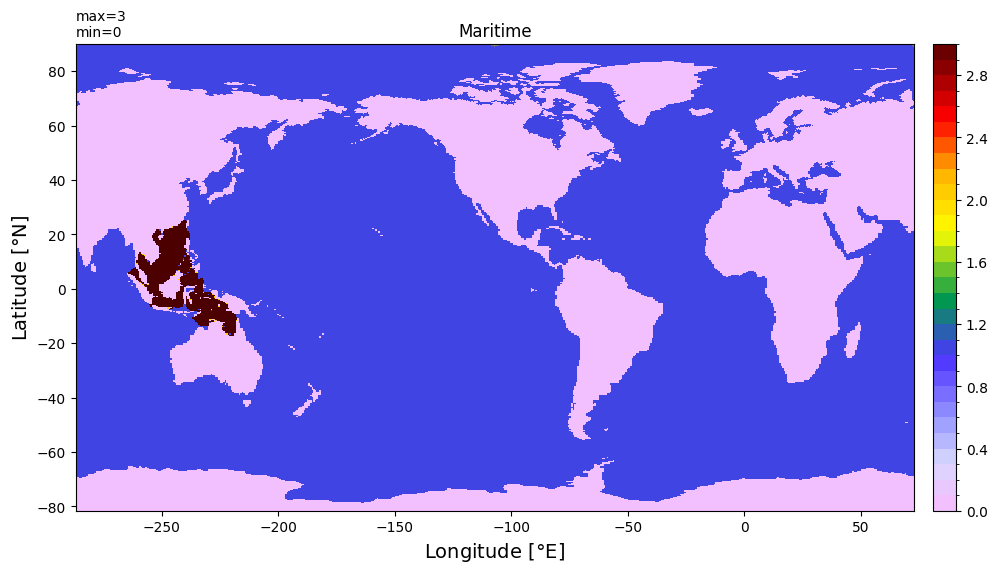

In [19]:
r = len(basin_code.region)-1
(basin_code[0,:]+basin_code[r,:]*2).values
xyplot((basin_code[0,:]+basin_code[r,:]*2).values, grd.tlon, grd.tlat,
          title=str(basin_code['region'][r].values))

#### SouthernOcean60S

In [20]:
# Expand dimensions to match `region` dimension
new_region_mask = xr.where(basin_code.sel(region='SouthernOcean') == 1, 1, 0).where(grd.tlat.rename({'ny':'yh','nx':'xh'})<=-60).fillna(0)

# Assign a new region index (e.g., 14 if original regions are indexed 0-13)
new_region_mask = new_region_mask.expand_dims(dim={"region": [len(basin_code.region)]})  # Change to the appropriate index

# Concatenate with the existing `basin_masks`
basin_code = xr.concat([basin_code, new_region_mask], dim="region")

# Update region name

# Convert region names to a list, modify the last element, and reassign
region_names = basin_code.region.values.tolist()
region_names[-1] = 'SouthernOcean60S'  # Replace last region name

# Reassign the modified region names to the dataset
basin_code = basin_code.assign_coords(region=("region", region_names))

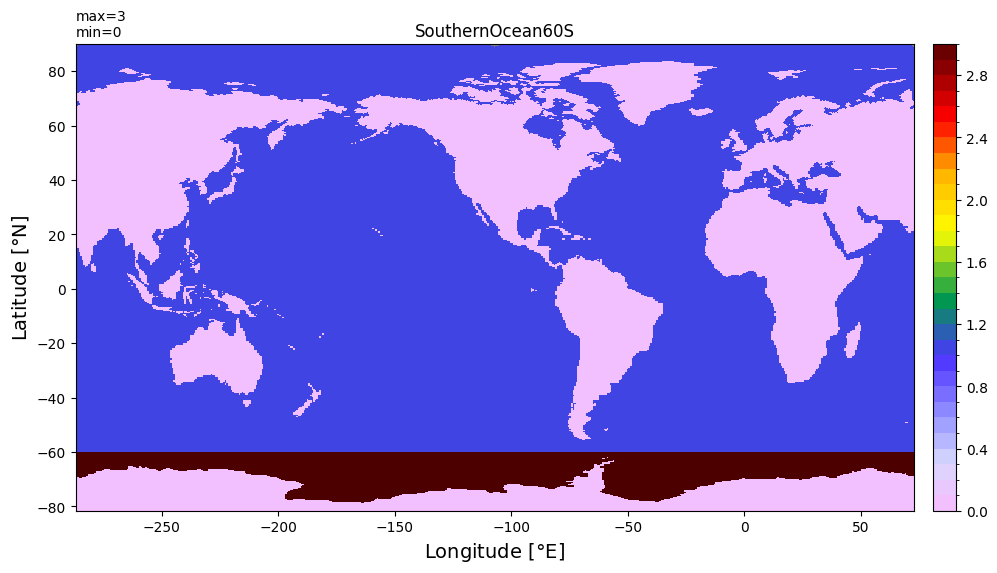

In [21]:
r = len(basin_code.region)-1
(basin_code[0,:]+basin_code[r,:]*2).values
xyplot((basin_code[0,:]+basin_code[r,:]*2).values, grd.tlon, grd.tlat,
          title=str(basin_code['region'][r].values))

### Save as netCDF

In [22]:
# Global attrs
basin_code.attrs['description'] = 'Basin masks for ' + grid_name
basin_code.attrs['author'] = author
basin_code.attrs['date'] = today
basin_code.attrs['infile'] = grd_path
basin_code.attrs['url'] = 'https://github.com/NCAR/tx2_3/basin_masks'
# save
fname = 'basin_masks_{}_{}.nc'.format(grid_name, today)

basin_code.to_netcdf(fname, encoding={'basin_masks': {'_FillValue': None}})